<a href="https://colab.research.google.com/github/ParasRajputt/Deep_Learning_Pytorch/blob/main/Chapter1_Pytorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch
from torch import nn

In [2]:
weight = 0.7
bias = 0.4
X = torch.arange(0,1,0.02).unsqueeze(dim=1)
y = weight * X + bias

In [12]:
train_split = int(0.8 *len(X))
X_train , y_train = X[:train_split],y[:train_split]
X_test , y_test = X[train_split:] , y[train_split:]

In [13]:
class LinearRegressionModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_layer = nn.Linear(in_features=1 ,
                                  out_features=1)

  def forward(self , x:torch.Tensor)-> torch.Tensor:
    return self.linear_layer(x)

In [14]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [15]:
model , model.state_dict()

(LinearRegressionModel(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [25]:
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(params = model.parameters(),
                            lr = 0.1)

In [26]:
epochs = 500
for epoch in range (epochs):
    model.train()
    y_pred = model(X_train)
    loss = loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()

    with torch.inference_mode():
        test_pred = model(X_test)

        test_loss = loss_fn(test_pred , y_test)

    if epoch % 100 == 0:
        print(f"epoch:{epoch} | Train loss :{loss} | Test Loss : {test_loss}")

epoch:0 | Train loss :0.007063752505928278 | Test Loss : 0.12885689735412598
epoch:100 | Train loss :0.007063752505928278 | Test Loss : 0.12885689735412598
epoch:200 | Train loss :0.007063752505928278 | Test Loss : 0.12885689735412598
epoch:300 | Train loss :0.007063752505928278 | Test Loss : 0.12885689735412598
epoch:400 | Train loss :0.007063752505928278 | Test Loss : 0.12885689735412598


In [27]:
print(f"Model weights: {model.state_dict()}")
print(f"True weight: {weight}, True bias: {bias}")

Model weights: OrderedDict({'linear_layer.weight': tensor([[0.6976]]), 'linear_layer.bias': tensor([0.4080])})
True weight: 0.7, True bias: 0.4


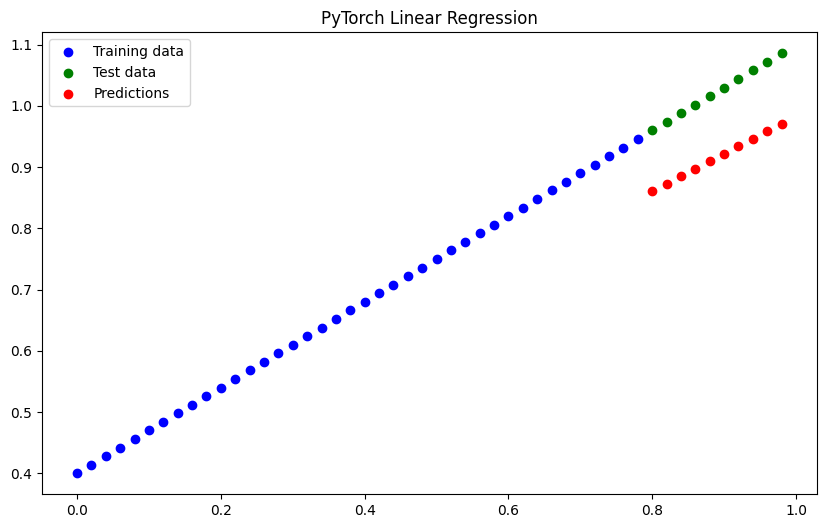

In [20]:
import matplotlib.pyplot as plt

model.eval()
with torch.inference_mode():
    y_pred = model(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(X_train, y_train, c='blue', label='Training data')
plt.scatter(X_test, y_test, c='green', label='Test data')
plt.scatter(X_test, y_pred, c='red', label='Predictions')
plt.legend()
plt.title('PyTorch Linear Regression')
plt.show()

In [28]:
from pathlib import Path

# Create models folder
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# Save model
MODEL_NAME = "linear_regression_model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

torch.save(obj=model.state_dict(), f=MODEL_SAVE_PATH)
print(f"Model saved to: {MODEL_SAVE_PATH}")

Model saved to: models/linear_regression_model.pth


In [29]:
loaded_model = LinearRegressionModel()
loaded_model.load_state_dict(torch.load(MODEL_SAVE_PATH))
loaded_model.eval()

with torch.inference_mode():
    loaded_model_preds = loaded_model(X_test)

print(torch.equal(test_pred, loaded_model_preds))  # should print True

True



1. Data Creation
   - torch.arange() to create sequential tensors
   - unsqueeze() to add dimensions

2. Train/Test Split
   - Manual split using index slicing
   - 80/20 split

3. Building Models with nn.Module
   - Define layers in __init__()
   - Forward pass in forward()
   - nn.Linear for linear transformation

4. Training Loop (most important)
   - model.train() → forward pass → loss →
     zero_grad → backward → optimizer.step()

5. Evaluation
   - model.eval() + torch.inference_mode()
   - Never track gradients during inference

6. Saving/Loading Models
   - torch.save(model.state_dict())
   - model.load_state_dict(torch.load())
   - Always save state_dict, not the whole model

Key insight: optimizer.step() is exactly your
numpy gradient descent — just automated for all parameters

